In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 先看文件夹里有什么
import os
for f in os.listdir(r'D:\Projects\mcdonalds'):
    print(f)


mcdonalds.csv


In [2]:
df = pd.read_csv(r'D:\Projects\mcdonalds\mcdonalds.csv', encoding='gbk')
print("形状:", df.shape)
print("\n前3行:\n", df.head(3))
print("\n列名:\n", df.columns.tolist())


形状: (1453, 15)

前3行:
   yummy convenient spicy fattening greasy fast cheap tasty expensive healthy  \
0    No        Yes    No       Yes     No  Yes   Yes    No       Yes      No   
1   Yes        Yes    No       Yes    Yes  Yes   Yes   Yes       Yes      No   
2    No        Yes   Yes       Yes    Yes  Yes    No   Yes       Yes     Yes   

  disgusting Like  Age      VisitFrequency  Gender  
0         No   -3   61  Every three months  Female  
1         No   +2   51  Every three months  Female  
2         No   +1   62  Every three months  Female  

列名:
 ['yummy', 'convenient', 'spicy', 'fattening', 'greasy', 'fast', 'cheap', 'tasty', 'expensive', 'healthy', 'disgusting', 'Like', 'Age', 'VisitFrequency', 'Gender']


In [3]:
print("=== info ===")
df.info()
print("\n=== 喜爱度分布 ===")
print(df['Like'].value_counts().sort_index())
print("\n=== 年龄描述 ===")
print(df['Age'].describe())
print("\n=== 性别分布 ===")
print(df['Gender'].value_counts())
print("\n=== 就餐频率 ===")
print(df['VisitFrequency'].value_counts())



=== info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1453 entries, 0 to 1452
Data columns (total 15 columns):
yummy             1453 non-null object
convenient        1453 non-null object
spicy             1453 non-null object
fattening         1453 non-null object
greasy            1453 non-null object
fast              1453 non-null object
cheap             1453 non-null object
tasty             1453 non-null object
expensive         1453 non-null object
healthy           1453 non-null object
disgusting        1453 non-null object
Like              1453 non-null object
Age               1453 non-null int64
VisitFrequency    1453 non-null object
Gender            1453 non-null object
dtypes: int64(1), object(14)
memory usage: 170.4+ KB

=== 喜爱度分布 ===
+1              152
+2              187
+3              229
+4              160
-1               58
-2               59
-3               73
-4               71
0               169
I hate it!-5    152
I love it!+5    143
Name: Li

In [4]:
# === 清洗喜爱度：统一转成数字 -5 到 +5 ===
import re

def clean_like(val):
    s = str(val).strip()
    # 提取数字
    match = re.findall(r'[-+]?\d+', s)
    if match:
        return int(match[0])
    return None

df['Like_score'] = df['Like'].apply(clean_like)
print("清洗后 Like_score 分布:")
print(df['Like_score'].value_counts().sort_index())


清洗后 Like_score 分布:
-5    152
-4     71
-3     73
-2     59
-1     58
 0    169
 1    152
 2    187
 3    229
 4    160
 5    143
Name: Like_score, dtype: int64


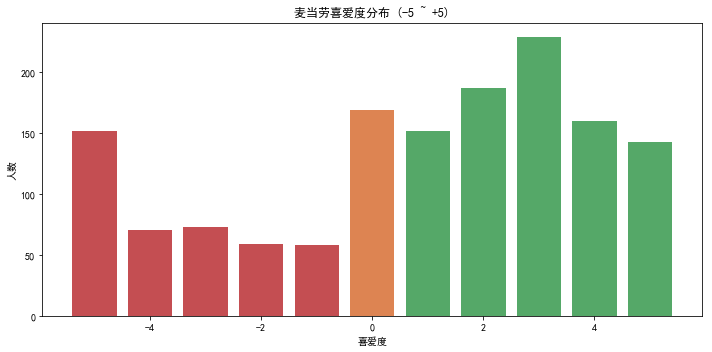

正面评价 (Like > 0): 871 (59.9%)
中性评价 (Like = 0): 169
负面评价 (Like < 0): 413 (28.4%)
平均喜爱度: 0.78


In [6]:
# === 喜爱度分布 ===
like_dist = df['Like_score'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
colors = ['#C44E52' if x < 0 else '#DD8452' if x == 0 else '#55A868' for x in like_dist.index]
plt.bar(like_dist.index, like_dist.values, color=colors)
plt.title('麦当劳喜爱度分布 (-5 ~ +5)')
plt.xlabel('喜爱度')
plt.ylabel('人数')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("正面评价 (Like > 0):", (df['Like_score'] > 0).sum(), f"({(df['Like_score'] > 0).mean()*100:.1f}%)")
print("中性评价 (Like = 0):", (df['Like_score'] == 0).sum())
print("负面评价 (Like < 0):", (df['Like_score'] < 0).sum(), f"({(df['Like_score'] < 0).mean()*100:.1f}%)")
print("平均喜爱度:", round(df['Like_score'].mean(), 2))




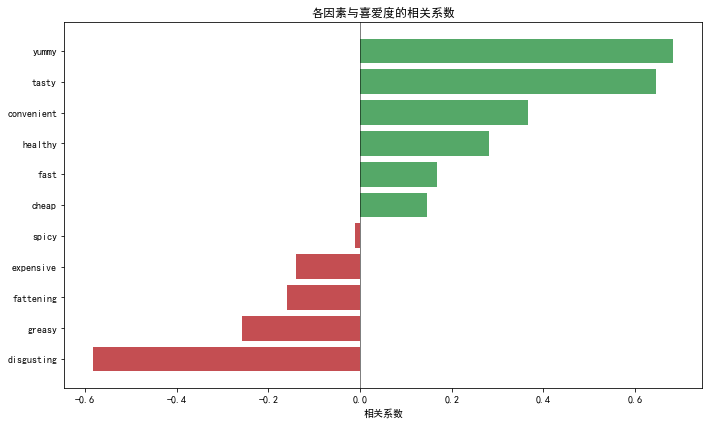

            因素   相关系数
0        yummy  0.683
7        tasty  0.645
1   convenient  0.366
9      healthy  0.281
5         fast  0.169
6        cheap  0.146
2        spicy -0.010
8    expensive -0.140
3    fattening -0.160
4       greasy -0.258
10  disgusting -0.582


In [7]:
# === 各因素与喜爱度的关系 ===
opinion_cols = ['yummy', 'convenient', 'spicy', 'fattening', 'greasy', 'fast', 'cheap', 'tasty', 'expensive', 'healthy', 'disgusting']

# Yes → 1, No → 0
for col in opinion_cols:
    df[col + '_num'] = df[col].map({'Yes': 1, 'No': 0})

# 各因素与喜爱度的相关系数
corr_list = []
for col in opinion_cols:
    r = df[col + '_num'].corr(df['Like_score'])
    corr_list.append({'因素': col, '相关系数': r.round(3)})

df_corr = pd.DataFrame(corr_list).sort_values('相关系数', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#55A868' if v > 0 else '#C44E52' for v in df_corr['相关系数']]
plt.barh(df_corr['因素'][::-1], df_corr['相关系数'][::-1], color=colors[::-1])
plt.title('各因素与喜爱度的相关系数')
plt.xlabel('相关系数')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print(df_corr)



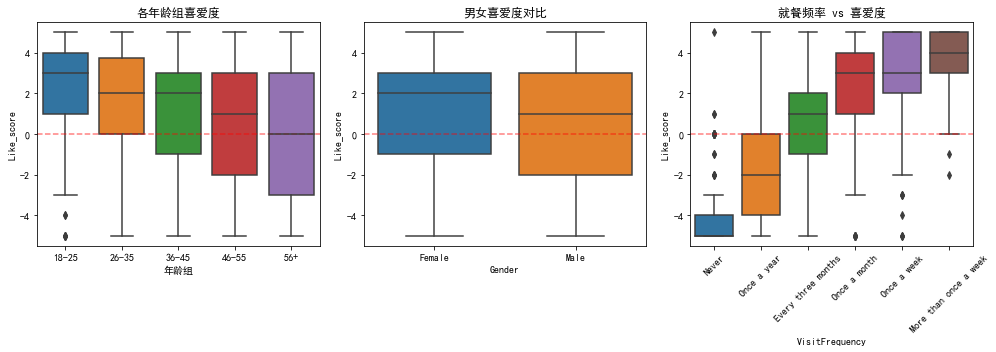

各年龄组平均喜爱度:
年龄组
18-25    2.22
26-35    1.58
36-45    0.87
46-55    0.28
56+     -0.06
Name: Like_score, dtype: float64

各频率平均喜爱度:
VisitFrequency
Every three months       0.58
More than once a week    3.85
Never                   -3.92
Once a month             2.22
Once a week              2.98
Once a year             -1.74
Name: Like_score, dtype: float64


In [8]:
# === 年龄 vs 喜爱度 ===
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 年龄分组
df['年龄组'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 80], labels=['18-25', '26-35', '36-45', '46-55', '56+'])

# 各年龄组喜爱度
sns.boxplot(x='年龄组', y='Like_score', data=df, ax=axes[0])
axes[0].set_title('各年龄组喜爱度')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)

# 性别喜爱度
sns.boxplot(x='Gender', y='Like_score', data=df, ax=axes[1])
axes[1].set_title('男女喜爱度对比')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)

# 就餐频率 vs 喜爱度
freq_order = ['Never', 'Once a year', 'Every three months', 'Once a month', 'Once a week', 'More than once a week']
df_freq = df[df['VisitFrequency'].isin(freq_order)]
sns.boxplot(x='VisitFrequency', y='Like_score', data=df_freq, order=freq_order, ax=axes[2])
axes[2].set_title('就餐频率 vs 喜爱度')
axes[2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("各年龄组平均喜爱度:")
print(df.groupby('年龄组')['Like_score'].mean().round(2))
print("\n各频率平均喜爱度:")
print(df_freq.groupby('VisitFrequency')['Like_score'].mean().round(2))



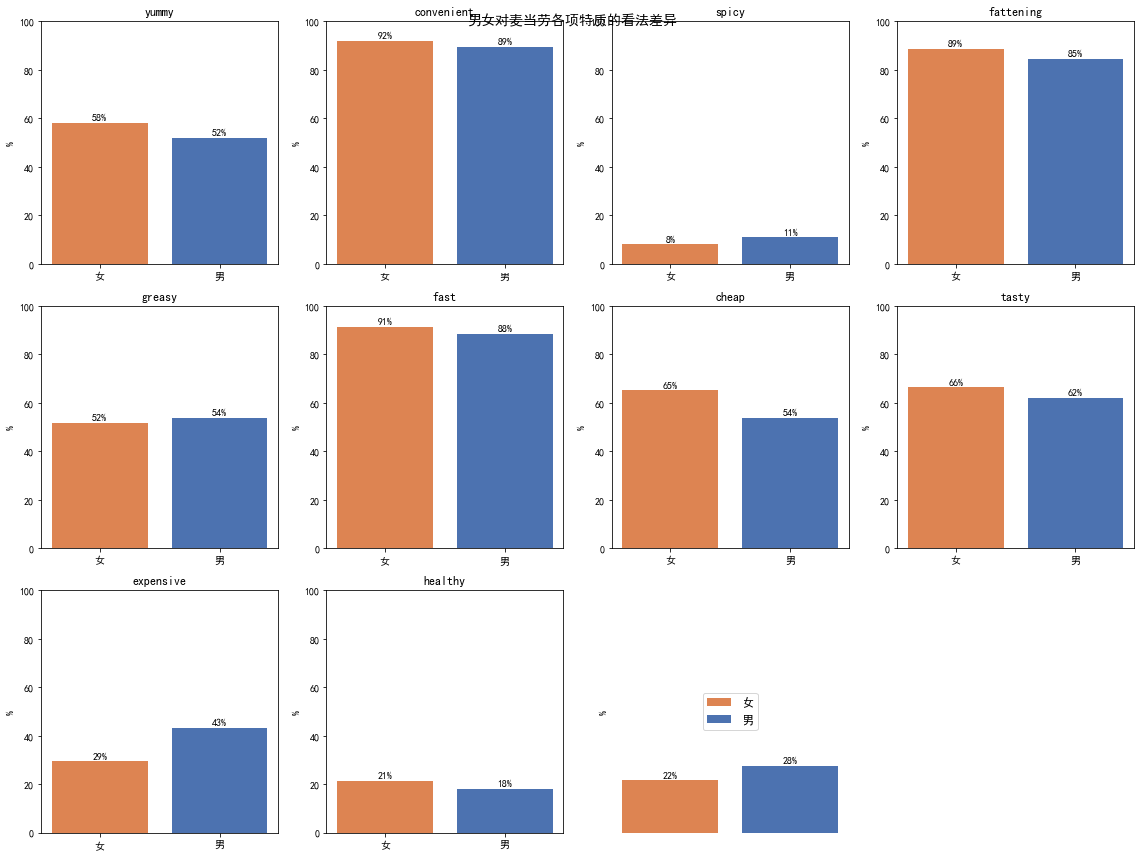

男性 vs 女性 喜爱度均值:
Gender
Female    0.92
Male      0.61
Name: Like_score, dtype: float64


In [10]:
# === 男女对不同因素的看法 ===
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(opinion_cols):
    cross = pd.crosstab(df[col], df['Gender'], normalize='columns') * 100
    if 'Yes' in cross.index:
        bars = axes[i].bar(['女', '男'], [cross.loc['Yes', 'Female'], cross.loc['Yes', 'Male']], 
                           color=['#DD8452', '#4C72B0'])
        axes[i].set_title(col)
        axes[i].set_ylabel('%')
        axes[i].set_ylim(0, 100)
        for bar, v in zip(bars, [cross.loc['Yes', 'Female'], cross.loc['Yes', 'Male']]):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                        f'{v:.0f}%', ha='center', fontsize=10)

# 隐藏最后一个空子图
axes[11].set_visible(False)

# 在右下角加图例
axes[10].bar([0], [0], color='#DD8452', label='女')
axes[10].bar([0], [0], color='#4C72B0', label='男')
axes[10].legend(fontsize=12, loc='center')
axes[10].set_xticks([])
axes[10].set_yticks([])
axes[10].set_title('')
axes[10].spines['top'].set_visible(False)
axes[10].spines['right'].set_visible(False)
axes[10].spines['bottom'].set_visible(False)
axes[10].spines['left'].set_visible(False)

plt.suptitle('男女对麦当劳各项特质的看法差异', fontsize=14)
plt.tight_layout()
plt.show()

print("男性 vs 女性 喜爱度均值:")
print(df.groupby('Gender')['Like_score'].mean().round(2))


麦当劳消费者分析报告
数据概况
1,453 份消费者调查，含品牌看法、喜爱度、年龄、性别、消费频率
yummy（0.68）和 tasty（0.65）是与喜爱度最强正相关的因素 方便（0.37）其次
消费者不为"辣""便宜"买单——这些跟喜爱度几乎无关
disgusting（-0.58）和 greasy（-0.26）是拖低喜爱度的主因
健康顾虑不决定性——healthy 的相关系数仍为正值

18-25 岁平均喜爱度 2.22，56+ 岁跌至 -0.06
每周多次光顾的人喜爱度 3.85，从不吃的人 -3.92——爱恨分明


女性平均喜爱度 0.92，男性 0.61
男女对特质看法有差异

麦当劳的核心资产是"好吃+方便"，最大的风险是消费者把它和"垃圾食品"划等号。年轻女性是最忠实的群体。
